In [2]:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import csv
import gc

## $U_y$ time series:

In [3]:
def U_read(file):
    with open(file) as f:
        #row_count = sum(1 for row in f)
        U = []
        u = []
        v = []
        w = []
        minv = []
        q1v = []
        q3v = []
        maxv = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            U.append(float(row['avg(U (Magnitude))']))  # Access by column header instead of column number
            u.append(float(row['avg(U (0))']))  
            v.append(float(row['avg(U (1))']))
            w.append(float(row['avg(U (2))']))
            minv.append(float(row['min(U (1))']))  
            maxv.append(float(row['max(U (1))']))
            q1v.append(float(row['q1(U (1))']))  
            q3v.append(float(row['q3(U (1))']))

            
        U = np.array(U)
        u = np.array(u)
        v = np.array(v)
        w = np.array(w)
        minv = np.array(minv)
        maxv = np.array(maxv)
        q1v = np.array(q1v)
        q3v = np.array(q3v)
        
        #x = x*100  #convert to cm
        #Umag = np.sqrt((u**2)+(v**2)+(w**2))*1000
        #print(Umag.shape)
        U_final = np.array((U*100,u*100,v*100,w*100,minv*100,q1v*100,q3v*100,maxv*100))#Umag
        
        return U_final

### Edrioasteroids

In [4]:
t = np.arange(0,41,1)
dir1 = '../stromatocystites/velocity/v0.1/postProcessing/'
dir2 = '../kailidiscus/velocity/v0.1/postProcessing/'
file = 'time_series.csv'
data_stromat = U_read(dir1 + file)
data_kaili = U_read(dir2 + file)

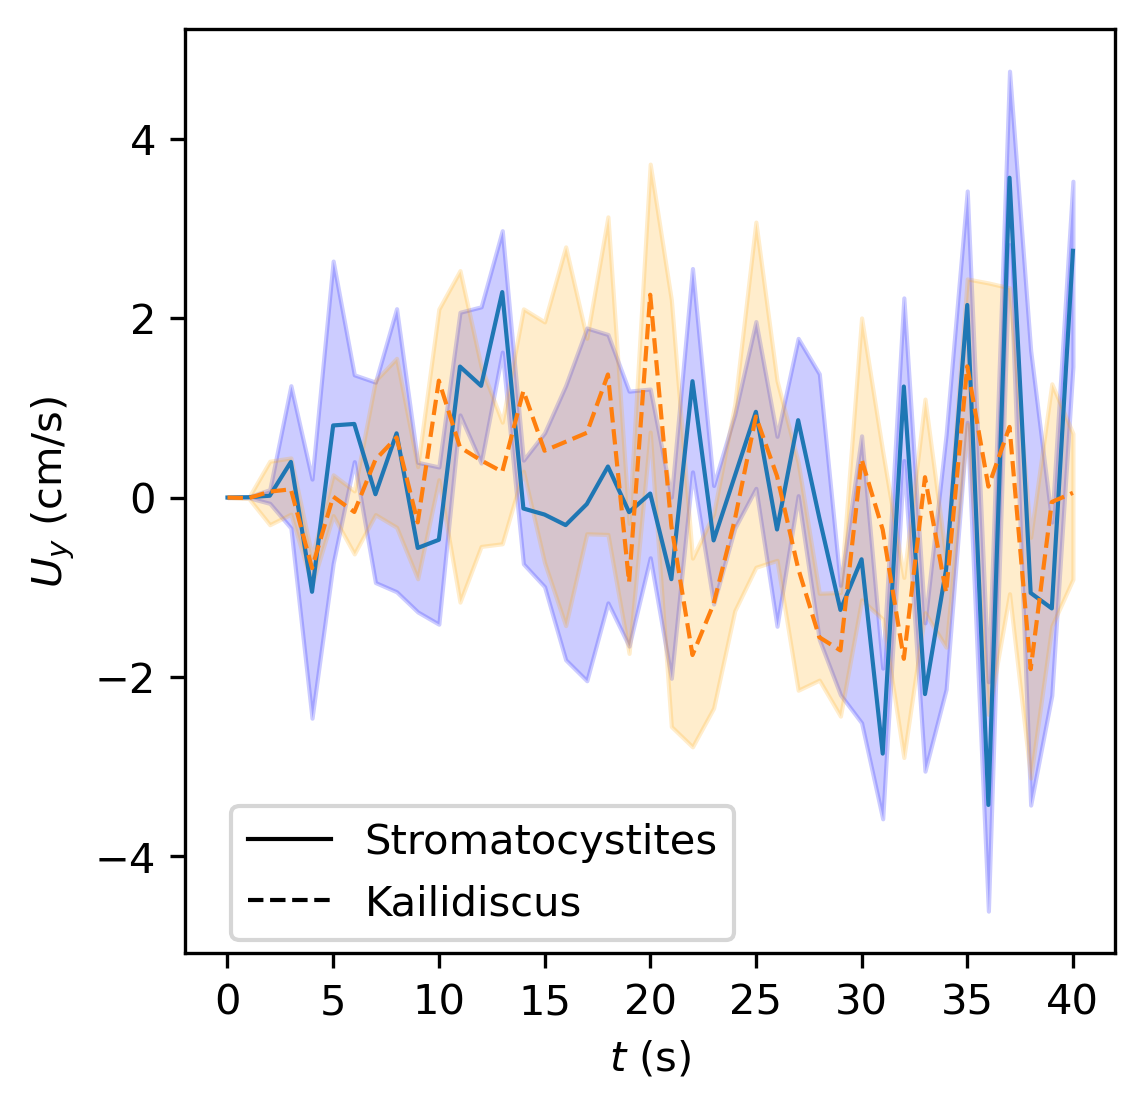

In [25]:
fig = plt.figure(dpi=300)
fig.set_size_inches(4, 4)
plt.plot(t, data_stromat[2], linewidth=1,  label='stromatocystites')
plt.plot(t, data_kaili[2], linestyle = '--', linewidth=1, label='kailidiscus')
plt.fill_between(t, data_stromat[5], data_stromat[6], color='blue', alpha=0.2)
plt.fill_between(t, data_kaili[5], data_kaili[6], color='orange', alpha=0.2)
plt.ylabel(r'$U_y$ (cm/s)')
plt.xlabel(r'$t$ (s)')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# create custom linestyle legend entries
solid_handle = Line2D([0], [0], color='k', linestyle='-', linewidth=1)
dashed_handle = Line2D([0], [0], color='k', linestyle='--', linewidth=1)

fig.legend(
    [solid_handle, dashed_handle],
    ['Stromatocystites', 'Kailidiscus'],
    loc=1,
    bbox_to_anchor=(0.6, 0.25),
)

plt.savefig('Uy_time_series_edrioasteroids.pdf', bbox_inches='tight')

### Gogiids:

In [27]:
t = np.arange(0,41,1)
dir3 = '../gogia_palmeri/velocity/v0.1/postProcessing/'
dir4 = '../gogia_spiralis/velocity/v0.1/postProcessing/'
file = 'time_series.csv'
data_palmeri = U_read(dir3 + file)
data_spiralis = U_read(dir4 + file)

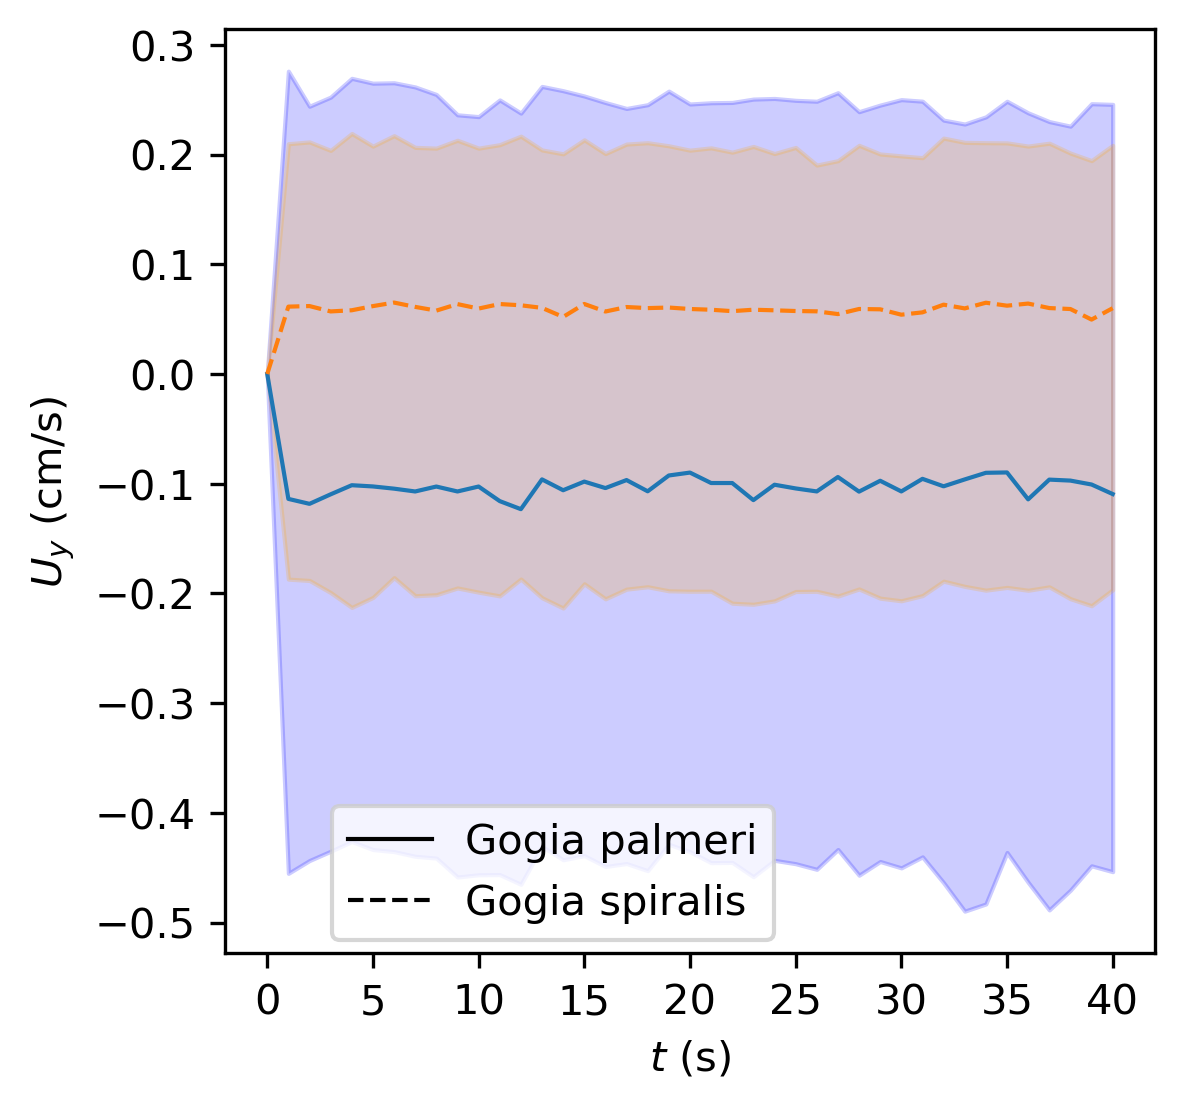

In [28]:
fig = plt.figure(dpi=300)
fig.set_size_inches(4, 4)
plt.plot(t, data_palmeri[2], linewidth=1,  label='Gogia palmeri')
plt.plot(t, data_spiralis[2], linestyle = '--', linewidth=1, label='Gogia spiralis')
plt.fill_between(t, data_palmeri[5], data_palmeri[6], color='blue', alpha=0.2)
plt.fill_between(t, data_spiralis[5], data_spiralis[6], color='orange', alpha=0.2)
plt.ylabel(r'$U_y$ (cm/s)')
plt.xlabel(r'$t$ (s)')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# create custom linestyle legend entries
solid_handle = Line2D([0], [0], color='k', linestyle='-', linewidth=1)
dashed_handle = Line2D([0], [0], color='k', linestyle='--', linewidth=1)

fig.legend(
    [solid_handle, dashed_handle],
    ['Gogia palmeri', 'Gogia spiralis'],
    loc=1,
    bbox_to_anchor=(0.6, 0.25),
)

plt.savefig('Uy_time_series_gogiids.pdf', bbox_inches='tight')

## FFT

In [6]:
def FFT_read(file, L):
    # Reads in FFT data from paraview, removes negative frequencies and computes Strouhal number based
    # on characteristic length provided, assuming free stream velocity of 0.1m/s.
    with open(file) as f:
        #row_count = sum(1 for row in f)
        print(file)
        freq = []
        Fx = []
        Fy = []

        reader = csv.DictReader(f, delimiter=',')
        for row in reader:
            freq.append(float(row['Frequency']))  # Access by column header instead of column number
            Fx.append(float(row['avg(U (1)):0']))  
            Fy.append(float(row['avg(U (1)):1']))  

        freq = np.array(freq)
        Fx = np.array(Fx)
        Fy = np.array(Fy)
        F = np.sqrt(Fx**2 + Fy**2) 
        # removing -ve frequencies
        freq_pos = freq[freq >= 0]
        F_pos = F[:len(freq_pos)]

        # Strouhal number: St = f*L/U
        U = 0.1 # free stream velocity
        strouhal = freq_pos*L/U
        
        FFT_final = np.array((strouhal,F_pos))#Umag
        
        return FFT_final

### Edrioasteroids

In [7]:
dir1 = '../stromatocystites/velocity/v0.1/postProcessing/'
dir2 = '../kailidiscus/velocity/v0.1/postProcessing/'
FFT_stromat = FFT_read(dir1 + 'FFT.csv', 0.03)
FFT_kaili = FFT_read(dir2 + 'FFT.csv', 0.03)


../stromatocystites/velocity/v0.1/postProcessing/FFT.csv
../kailidiscus/velocity/v0.1/postProcessing/FFT.csv


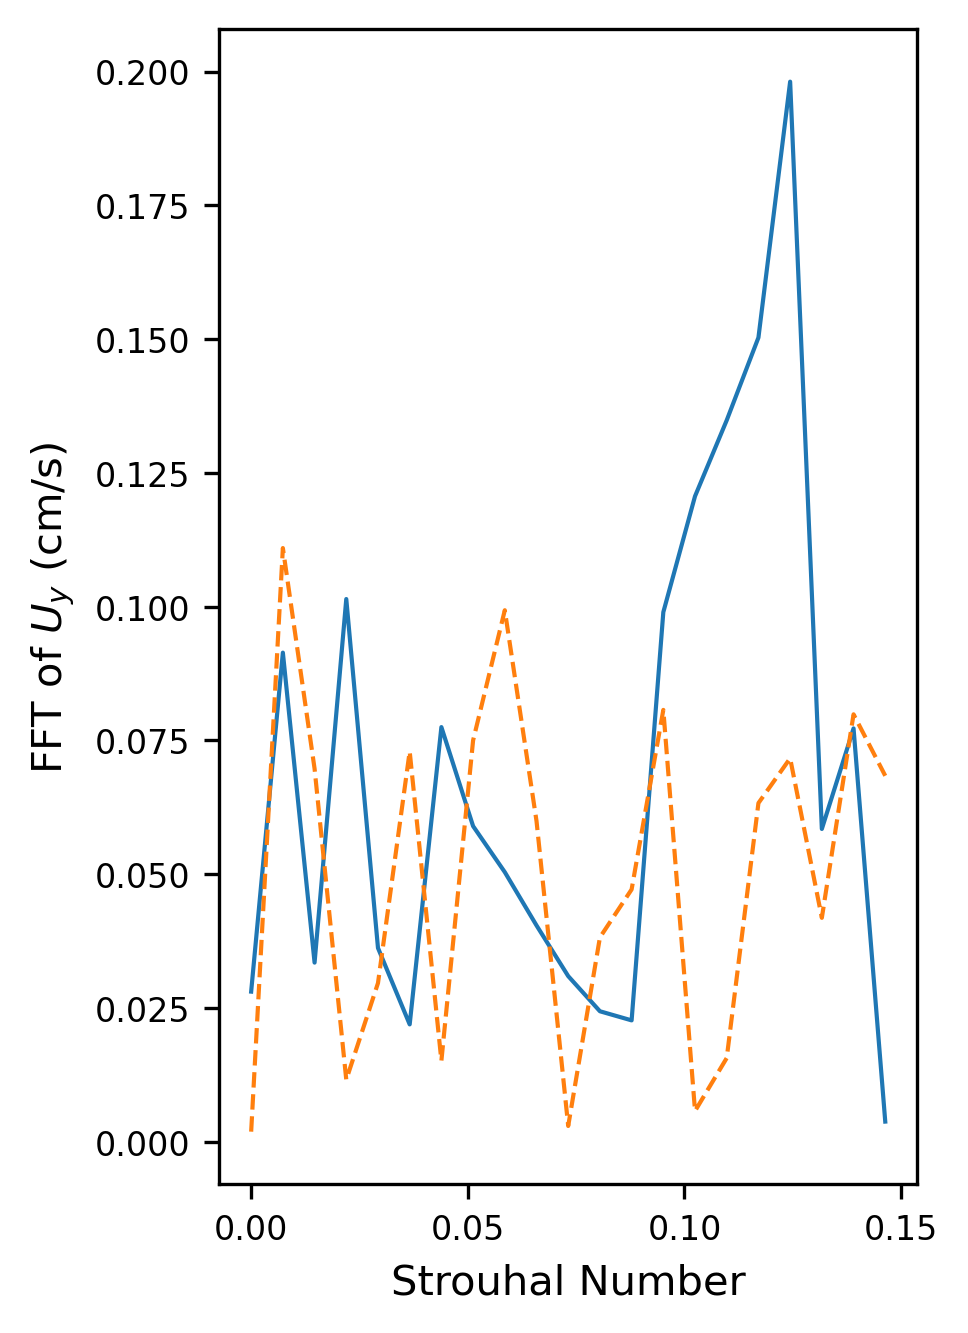

In [22]:
fig = plt.figure(dpi=300)
fig.set_size_inches(3, 5)
plt.plot(FFT_stromat[0], FFT_stromat[1], linewidth=1,  label='stromatocystites')
plt.plot(FFT_kaili[0], FFT_kaili[1], linestyle = '--', linewidth=1, label='kailidiscus')
#plt.xscale('log')
#plt.yscale('log')
#plt.xlim(0,0.5)
plt.xlabel('Strouhal Number')
plt.ylabel(r'FFT of $U_y$ (cm/s)')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.savefig('FFT_Uy_edrioasteroids.pdf', bbox_inches='tight')

### Gogiids

In [29]:
dir3 = '../gogia_palmeri/velocity/v0.1/postProcessing/'
dir4 = '../gogia_spiralis/velocity/v0.1/postProcessing/'
FFT_palmeri = FFT_read(dir3 + 'FFT.csv', 0.13)
FFT_spiralis = FFT_read(dir4 + 'FFT.csv', 0.065)

../gogia_palmeri/velocity/v0.1/postProcessing/FFT.csv
../gogia_spiralis/velocity/v0.1/postProcessing/FFT.csv


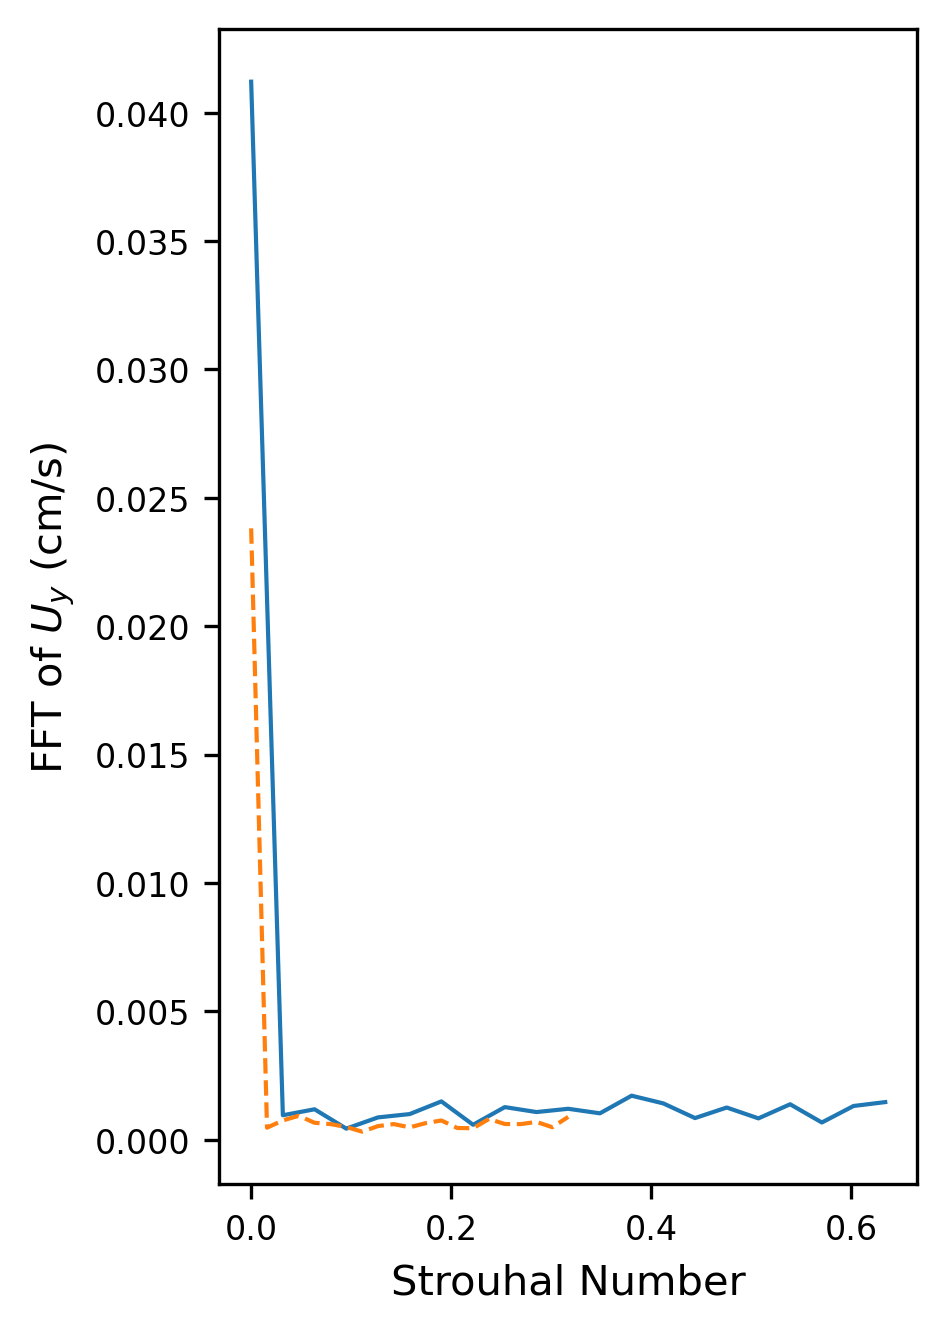

In [30]:
fig = plt.figure(dpi=300)
fig.set_size_inches(3, 5)
plt.plot(FFT_palmeri[0], FFT_palmeri[1], linewidth=1,  label='Gogia palmeri')
plt.plot(FFT_spiralis[0], FFT_spiralis[1], linestyle = '--', linewidth=1, label='Gogia spiralis')
#plt.xscale('log')
#plt.yscale('log')
#plt.xlim(0,0.5)
plt.xlabel('Strouhal Number')
plt.ylabel(r'FFT of $U_y$ (cm/s)')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.savefig('FFT_Uy_gogiids.pdf', bbox_inches='tight')